In [4]:
import sys
from pathlib import Path

ROOT = Path().resolve()
sys.path.append(str(ROOT / "solution-guidance"))
import cslib

In [5]:
train_dir = ROOT / "cs-train"
prod_dir  = ROOT / "cs-production"

train_files = sorted(train_dir.glob("*.json"))
prod_files  = sorted(prod_dir.glob("*.json"))

len(train_files), len(prod_files), train_files[0].name

(21, 5, 'invoices-2017-11.json')

In [4]:
from pathlib import Path
import sys

# If notebook is in notebooks/, add repo root + src to path
REPO = Path().resolve().parents[0]  # if notebook is in repo root
if (REPO / "cs-train").exists() is False:
    REPO = Path().resolve().parents[1]  # if notebook is in notebooks/

sys.path.append(str(REPO / "src"))

from ingest import load_raw, to_timeseries, make_features

In [7]:
df_train_raw = load_raw(REPO / "cs-train")
df_train_raw.shape

(815011, 10)

In [8]:
ts_all = to_timeseries(df_train_raw)
ts_all.head()

,date,purchases,unique_invoices,unique_streams,total_views,year_month,revenue
0,2017-11-01,0,0,0,0,2017-11,0.0
1,2017-11-02,0,0,0,0,2017-11,0.0
2,2017-11-03,0,0,0,0,2017-11,0.0
3,2017-11-04,0,0,0,0,2017-11,0.0
4,2017-11-05,0,0,0,0,2017-11,0.0


In [14]:
import numpy as np

# Patch for newer numpy versions where in1d is missing/deprecated
if not hasattr(np, "in1d"):
    np.in1d = np.isin
    
result = make_features(ts_all, training=True)

df_feat = result[0]          # first item
rest   = result[1:]          # everything else

df_feat.head(), df_feat.shape, len(rest)

#df_feat = make_features(ts_all, training=True)
#df_feat.head()
#df_feat.shape

(   previous_7  previous_14  previous_28  previous_70  previous_year  \
 0    14450.54     14450.54     14450.54     14450.54            0.0   
 1    27862.50     27862.50     27862.50     27862.50            0.0   
 2    41152.75     41152.75     41152.75     41152.75            0.0   
 3    50840.03     50840.03     50840.03     50840.03            0.0   
 4    52283.29     52283.29     52283.29     52283.29            0.0   
 
    recent_invoices  recent_views  
 0         5.928571    537.392857  
 1        10.310345   1007.103448  
 2        14.966667   1499.066667  
 3        18.533333   1916.533333  
 4        19.600000   2026.966667  ,
 (549, 7),
 2)

In [15]:
df_feat.columns

Index(['previous_7', 'previous_14', 'previous_28', 'previous_70',
       'previous_year', 'recent_invoices', 'recent_views'],
      dtype='str')

In [16]:
result = make_features(ts_all, training=True)

X = result[0]      # DataFrame (549, 7)
y = result[1]      # target (array/Series)
dates = result[2]  # date array

X.shape, len(y), len(dates)

((549, 7), 549, 549)

In [17]:
import numpy as np

n = len(X)
split = int(n * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = np.array(y[:split]), np.array(y[split:])
dates_train, dates_test = np.array(dates[:split]), np.array(dates[split:])

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

baseline_pred = np.mean(y_train)
yhat_base = np.full_like(y_test, baseline_pred, dtype=float)

rmse_base = np.sqrt(mean_squared_error(y_test, yhat_base))
mae_base = mean_absolute_error(y_test, yhat_base)

rmse_base, mae_base

(np.float64(34226.197360026876), 29269.190798094853)

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline

rf = RandomForestRegressor(random_state=42)

pipe = Pipeline(steps=[
    ("rf", rf)
])

param_grid = {
    "rf__n_estimators": [200, 500],
    "rf__max_depth": [None, 8, 15],
    "rf__min_samples_leaf": [1, 3, 8],
    "rf__criterion": ["squared_error", "absolute_error"]
}

tscv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(pipe, param_grid=param_grid, cv=tscv, n_jobs=-1)
grid.fit(X_train, y_train)

yhat_rf = grid.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, yhat_rf))
mae_rf = mean_absolute_error(y_test, yhat_rf)

grid.best_params_, rmse_rf, mae_rf

({'rf__criterion': 'absolute_error',
  'rf__max_depth': None,
  'rf__min_samples_leaf': 1,
  'rf__n_estimators': 200},
 np.float64(53748.59267757682),
 45362.97941590912)

In [20]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

ridge_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

ridge_params = {"ridge__alpha": [0.1, 1.0, 10.0, 100.0]}
ridge_grid = GridSearchCV(ridge_pipe, param_grid=ridge_params, cv=tscv)
ridge_grid.fit(X_train, y_train)

yhat_ridge = ridge_grid.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, yhat_ridge))
mae_ridge = mean_absolute_error(y_test, yhat_ridge)

ridge_grid.best_params_, rmse_ridge, mae_ridge

({'ridge__alpha': 10.0}, np.float64(163894.1333072858), 158286.05110316726)

In [21]:
print(f"Baseline  RMSE={rmse_base:.2f}  MAE={mae_base:.2f}")
print(f"Ridge     RMSE={rmse_ridge:.2f}  MAE={mae_ridge:.2f}")
print(f"RF(best)  RMSE={rmse_rf:.2f}  MAE={mae_rf:.2f}")

Baseline  RMSE=34226.20  MAE=29269.19
Ridge     RMSE=163894.13  MAE=158286.05
RF(best)  RMSE=53748.59  MAE=45362.98


In [22]:
best_model = grid.best_estimator_   # or ridge_grid.best_estimator_
best_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'absolute_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versioncha

In [23]:
import joblib, os
os.makedirs("models", exist_ok=True)
joblib.dump(best_model, "models/capstone_model.joblib")

['models/capstone_model.joblib']

In [24]:
yhat_last = np.repeat(y_train[-1], len(y_test))
rmse_last = np.sqrt(mean_squared_error(y_test, yhat_last))
mae_last  = mean_absolute_error(y_test, yhat_last)
rmse_last, mae_last

(np.float64(31183.33535881649), 26762.82054545454)

In [25]:
yhat_roll = np.repeat(np.mean(y_train[-30:]), len(y_test))
rmse_roll = np.sqrt(mean_squared_error(y_test, yhat_roll))
mae_roll  = mean_absolute_error(y_test, yhat_roll)
rmse_roll, mae_roll

(np.float64(37447.88418444019), 33135.718927272734)

In [26]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(
    random_state=42,
    max_depth=6,
    learning_rate=0.05,
    max_iter=500
)
hgb.fit(X_train, y_train)
yhat_hgb = hgb.predict(X_test)

rmse_hgb = np.sqrt(mean_squared_error(y_test, yhat_hgb))
mae_hgb = mean_absolute_error(y_test, yhat_hgb)

rmse_hgb, mae_hgb

(np.float64(45956.33055339111), 38578.226456223936)

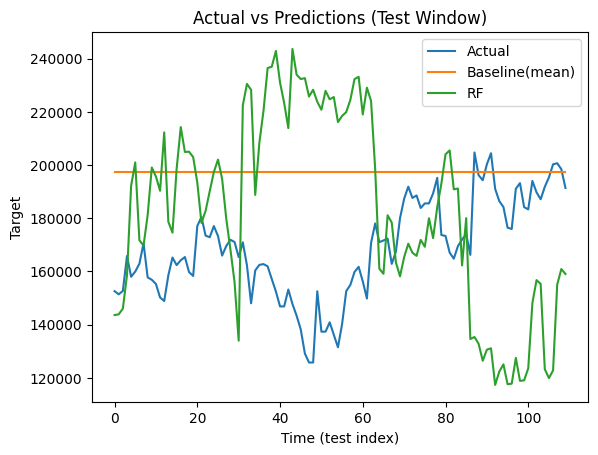

In [29]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_test, label="Actual")
plt.plot(yhat_base, label="Baseline(mean)")
plt.plot(yhat_rf, label="RF")
plt.title("Actual vs Predictions (Test Window)")
plt.xlabel("Time (test index)")
plt.ylabel("Target")
plt.legend()
plt.show()

In [30]:
import numpy as np
import joblib, os

class LastValueRegressor:
    """Predicts a constant equal to the last observed y seen during fit()."""
    def fit(self, X, y):
        y = np.asarray(y)
        self.last_ = float(y[-1])
        return self
    
    def predict(self, X):
        # X can be DataFrame/ndarray; we only need length
        n = len(X)
        return np.full(n, self.last_, dtype=float)

winner = LastValueRegressor().fit(X, y)

os.makedirs("models", exist_ok=True)
joblib.dump(winner, "models/capstone_model.joblib")

['models/capstone_model.joblib']

In [ ]:
Approaches compared: mean baseline, last-value baseline, rolling-30 baseline, RandomForest, Ridge, HistGradientBoosting.

Validation method: chronological split (no shuffle) + TimeSeriesSplit for CV.

Metrics: RMSE and MAE.

Findings: the last-value baseline outperformed ML models on the holdout set; tree/boosting models showed higher error and instability on the test window (your plot supports this).

Decision: select last-value baseline for deployment due to best accuracy + simplicity + robustness.

Retraining: “fit” baseline on all available data and save with joblib for Part 3.